<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>GraphRAG</h1>
<h1>The Graph: build, query & analyze with NetworkX</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

import torch

import watermark

%load_ext watermark
%matplotlib inline

We start by print out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.15.0

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 44191938ab62c43da1cc2feb9fa73f73247587e9

json      : 2.0.9
matplotlib: 3.11.0
networkx  : 3.6.1
torch     : 2.12.1
watermark : 2.6.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

And detect what hardware we're working with

In [4]:
if torch.cuda.is_available():
    DEVICE = "cuda"          # NVIDIA GPU
elif torch.backends.mps.is_available():
    DEVICE = "mps"           # Apple Silicon GPU
else:
    DEVICE = "cpu"
    
print(f"models will run on: {DEVICE}")

models will run on: mps


In [5]:
# --- Checkpoint system ----------------------------------------------------------
# Every part of this workshop READS its inputs from, and WRITES its outputs to,
# a shared `checkpoints/` directory next to the notebooks. If an expected
# checkpoint is missing (you skipped a part, or a stage failed on your machine),
# we fall back to built-in data so THIS notebook still runs end to end.
# That mirrors good workshop practice: nobody gets stranded because an earlier
# stage broke — you load the checkpoint and keep moving.
CKPT = Path("checkpoints")
CKPT.mkdir(exist_ok=True)

def save_text(name, text):
    (CKPT / name).write_text(text, encoding="utf-8")
    print(f"[checkpoint] saved  {CKPT / name}  ({len(text):,} chars)")

def load_text(name, fallback=None):
    p = CKPT / name
    if p.exists():
        print(f"[checkpoint] loaded {p}")
        return p.read_text(encoding="utf-8")
    print(f"[checkpoint] {p} NOT FOUND — using built-in fallback data")
    return fallback

def save_jsonl(name, rows):
    with open(CKPT / name, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r) + "\n")
    print(f"[checkpoint] saved  {CKPT / name}  ({len(rows)} rows)")

def load_jsonl(name, fallback=None):
    p = CKPT / name
    if p.exists():
        rows = [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]
        print(f"[checkpoint] loaded {p}  ({len(rows)} rows)")
        return rows
    print(f"[checkpoint] {p} NOT FOUND — using built-in fallback data")
    return fallback

In [6]:
# --- CHECKPOINT IN: triples.jsonl ---------------------------------------------------
FALLBACK_TRIPLES = [
    {"head": "Marie Curie",          "relation": "country of citizenship", "tail": "Poland"},
    {"head": "Marie Curie",          "relation": "country of citizenship", "tail": "France"},
    {"head": "Marie Curie",          "relation": "occupation",             "tail": "physicist"},
    {"head": "Marie Curie",          "relation": "occupation",             "tail": "chemist"},
    {"head": "Marie Curie",          "relation": "field of work",          "tail": "radioactivity"},
    {"head": "Marie Curie",          "relation": "place of birth",         "tail": "Warsaw"},
    {"head": "Marie Curie",          "relation": "educated at",            "tail": "University of Paris"},
    {"head": "Marie Curie",          "relation": "employer",               "tail": "University of Paris"},
    {"head": "Marie Curie",          "relation": "award received",         "tail": "Nobel Prize in Physics"},
    {"head": "Pierre Curie",         "relation": "occupation",             "tail": "physicist"},
    {"head": "Pierre Curie",         "relation": "country of citizenship", "tail": "France"},
    {"head": "Pierre Curie",         "relation": "award received",         "tail": "Nobel Prize in Physics"},
    {"head": "Henri Becquerel",      "relation": "award received",         "tail": "Nobel Prize in Physics"},
    {"head": "Marie Curie",          "relation": "spouse",                 "tail": "Pierre Curie"},
    {"head": "Pierre Curie",         "relation": "spouse",                 "tail": "Marie Curie"},
    {"head": "Curie Institute",      "relation": "founded by",             "tail": "Marie Curie"},
    {"head": "Curie Institute",      "relation": "located in",             "tail": "Paris"},
    {"head": "Curie Institute",      "relation": "inception",              "tail": "1920"},
    {"head": "Marie Curie",          "relation": "child",                  "tail": "Irene Joliot-Curie"},
    {"head": "Irene Joliot-Curie",   "relation": "occupation",             "tail": "chemist"},
    {"head": "Irene Joliot-Curie",   "relation": "award received",         "tail": "Nobel Prize in Chemistry"},
    {"head": "Irene Joliot-Curie",   "relation": "spouse",                 "tail": "Frederic Joliot-Curie"},
    {"head": "Frederic Joliot-Curie","relation": "spouse",                 "tail": "Irene Joliot-Curie"},
    {"head": "Frederic Joliot-Curie","relation": "award received",         "tail": "Nobel Prize in Chemistry"},
    {"head": "Pierre Curie",         "relation": "date of death",          "tail": "1906"},
]

rows = load_jsonl("triples.jsonl", fallback=FALLBACK_TRIPLES)
triples = [(r["head"], r["relation"], r["tail"]) for r in rows]
print(f"\n{len(triples)} triples ready; first few:")
for t in triples[:5]:
    print("  ", t)

[checkpoint] checkpoints/triples.jsonl NOT FOUND — using built-in fallback data

25 triples ready; first few:
   ('Marie Curie', 'country of citizenship', 'Poland')
   ('Marie Curie', 'country of citizenship', 'France')
   ('Marie Curie', 'occupation', 'physicist')
   ('Marie Curie', 'occupation', 'chemist')
   ('Marie Curie', 'field of work', 'radioactivity')


---
## 3.1 Build the graph

In [7]:
G = nx.MultiDiGraph()

for head, rel, tail in triples:
    # add_edge auto-creates missing nodes. The relation label rides along as an
    # edge attribute — the graph-native form of a typed edge.
    G.add_edge(head, tail, relation=rel)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Peek at a few edges in (head)-[relation]->(tail) form:
for h, t, data in list(G.edges(data=True))[:10]:
    print(f"  ({h}) -[{data['relation']}]-> ({t})")

Graph: 18 nodes, 25 edges
  (Marie Curie) -[country of citizenship]-> (Poland)
  (Marie Curie) -[country of citizenship]-> (France)
  (Marie Curie) -[occupation]-> (physicist)
  (Marie Curie) -[occupation]-> (chemist)
  (Marie Curie) -[field of work]-> (radioactivity)
  (Marie Curie) -[place of birth]-> (Warsaw)
  (Marie Curie) -[educated at]-> (University of Paris)
  (Marie Curie) -[employer]-> (University of Paris)
  (Marie Curie) -[award received]-> (Nobel Prize in Physics)
  (Marie Curie) -[spouse]-> (Pierre Curie)


## 3.2 Querying: plain-Python graph traversal

Everything a query language (like Cypher) would give us, we write as small functions. Two workhorses that Part 4's chatbot will reuse:

- `facts_about(entity)` — the entity's full neighborhood, both directions, as readable facts. This is *local* retrieval.
- `path_between(a, b)` — the shortest chain of facts connecting two entities. This is the *multi-hop* capability no chunk-similarity system has.

In [8]:
def facts_about(entity):
    """All edges touching an entity, in both directions, as readable facts."""
    facts = []
    if entity not in G:
        return facts
    for _, tail, d in G.out_edges(entity, data=True):      # entity as head
        facts.append(f"{entity} —{d['relation']}→ {tail}")
    for head, _, d in G.in_edges(entity, data=True):       # entity as tail
        facts.append(f"{head} —{d['relation']}→ {entity}")
    return facts

def path_between(a, b):
    """Shortest chain of facts connecting two entities. We search the
    UNDIRECTED view: for connectivity questions we usually don't care which
    way the edges point."""
    try:
        nodes = nx.shortest_path(G.to_undirected(), a, b)
    except (nx.NodeNotFound, nx.NetworkXNoPath):
        return None
    hops = []
    for u, v in zip(nodes, nodes[1:]):                     # re-attach labels
        edge = (G.get_edge_data(u, v) or G.get_edge_data(v, u))
        rel = list(edge.values())[0]["relation"]
        hops.append(f"{u} —{rel}— {v}")
    return hops

# Try them on the most connected node in the graph:
hub = max(G.nodes, key=lambda n: G.degree(n))
print(f"Most connected entity: {hub}\n")
for f in facts_about(hub)[:8]:
    print("  ", f)

Most connected entity: Marie Curie

   Marie Curie —country of citizenship→ Poland
   Marie Curie —country of citizenship→ France
   Marie Curie —occupation→ physicist
   Marie Curie —occupation→ chemist
   Marie Curie —field of work→ radioactivity
   Marie Curie —place of birth→ Warsaw
   Marie Curie —educated at→ University of Paris
   Marie Curie —employer→ University of Paris


In [9]:
# A multi-hop traversal — pick two entities and connect them.
# With the fallback triples, Marie Curie → Frederic Joliot-Curie is a nice
# 2-hop chain (through Irene). With a live wikitext slice, substitute two
# entities from YOUR graph (see the PageRank list below for candidates).
a, b = hub, sorted(G.nodes, key=lambda n: -G.degree(n))[3]
path = path_between(a, b)
print(f"Path from '{a}' to '{b}':")
print("   " + ("  →  ".join(path) if path else "(no path — different components)"))

Path from 'Marie Curie' to 'Nobel Prize in Physics':
   Marie Curie —award received— Nobel Prize in Physics


## 3.3 Graph algorithms: finding structure we didn't put there

This is the payoff of a *real* graph over a pile of triples: sixty years of graph theory now applies to our text, for free.

- **PageRank** — which entities are structurally central (linked from many linked places)?
- **Connected components** — is the graph one world, or many islands? *Many small islands is the classic smell of skipped or failed coref*: fragments that should connect through a shared entity, but don't.
- **Community detection** — clusters of densely-linked entities ≈ topics. (This is the primitive behind GraphRAG-style community summaries.)

In [10]:
# 1) PageRank — most central entities. (PageRank wants a simple digraph, so we
#    collapse parallel edges for the computation only.)
pr = nx.pagerank(nx.DiGraph(G))
print("Most central entities (PageRank):")
for node, score in sorted(pr.items(), key=lambda kv: -kv[1])[:8]:
    print(f"  {score:.4f}  {node}")

# 2) Connected components
comps = sorted(nx.connected_components(G.to_undirected()), key=len, reverse=True)
print(f"\n{len(comps)} connected components; largest has {len(comps[0])} nodes")

# 3) Community detection
communities = greedy_modularity_communities(G.to_undirected())
print(f"\n{len(communities)} communities found; first two:")
for com in list(communities)[:2]:
    print("  ", sorted(com)[:6], "…" if len(com) > 6 else "")

Most central entities (PageRank):
  0.0878  Nobel Prize in Physics
  0.0866  Nobel Prize in Chemistry
  0.0714  Irene Joliot-Curie
  0.0658  chemist
  0.0607  Frederic Joliot-Curie
  0.0597  Marie Curie
  0.0533  France
  0.0533  physicist

1 connected components; largest has 18 nodes

4 communities found; first two:
   ['1906', 'France', 'Henri Becquerel', 'Nobel Prize in Physics', 'Pierre Curie', 'physicist'] 
   ['Marie Curie', 'Poland', 'University of Paris', 'Warsaw', 'radioactivity'] 


## 3.4 Visualize a neighborhood

Whole-graph drawings become hairballs fast; an **ego graph** (one entity plus its k-hop neighborhood) is the honest, readable view.

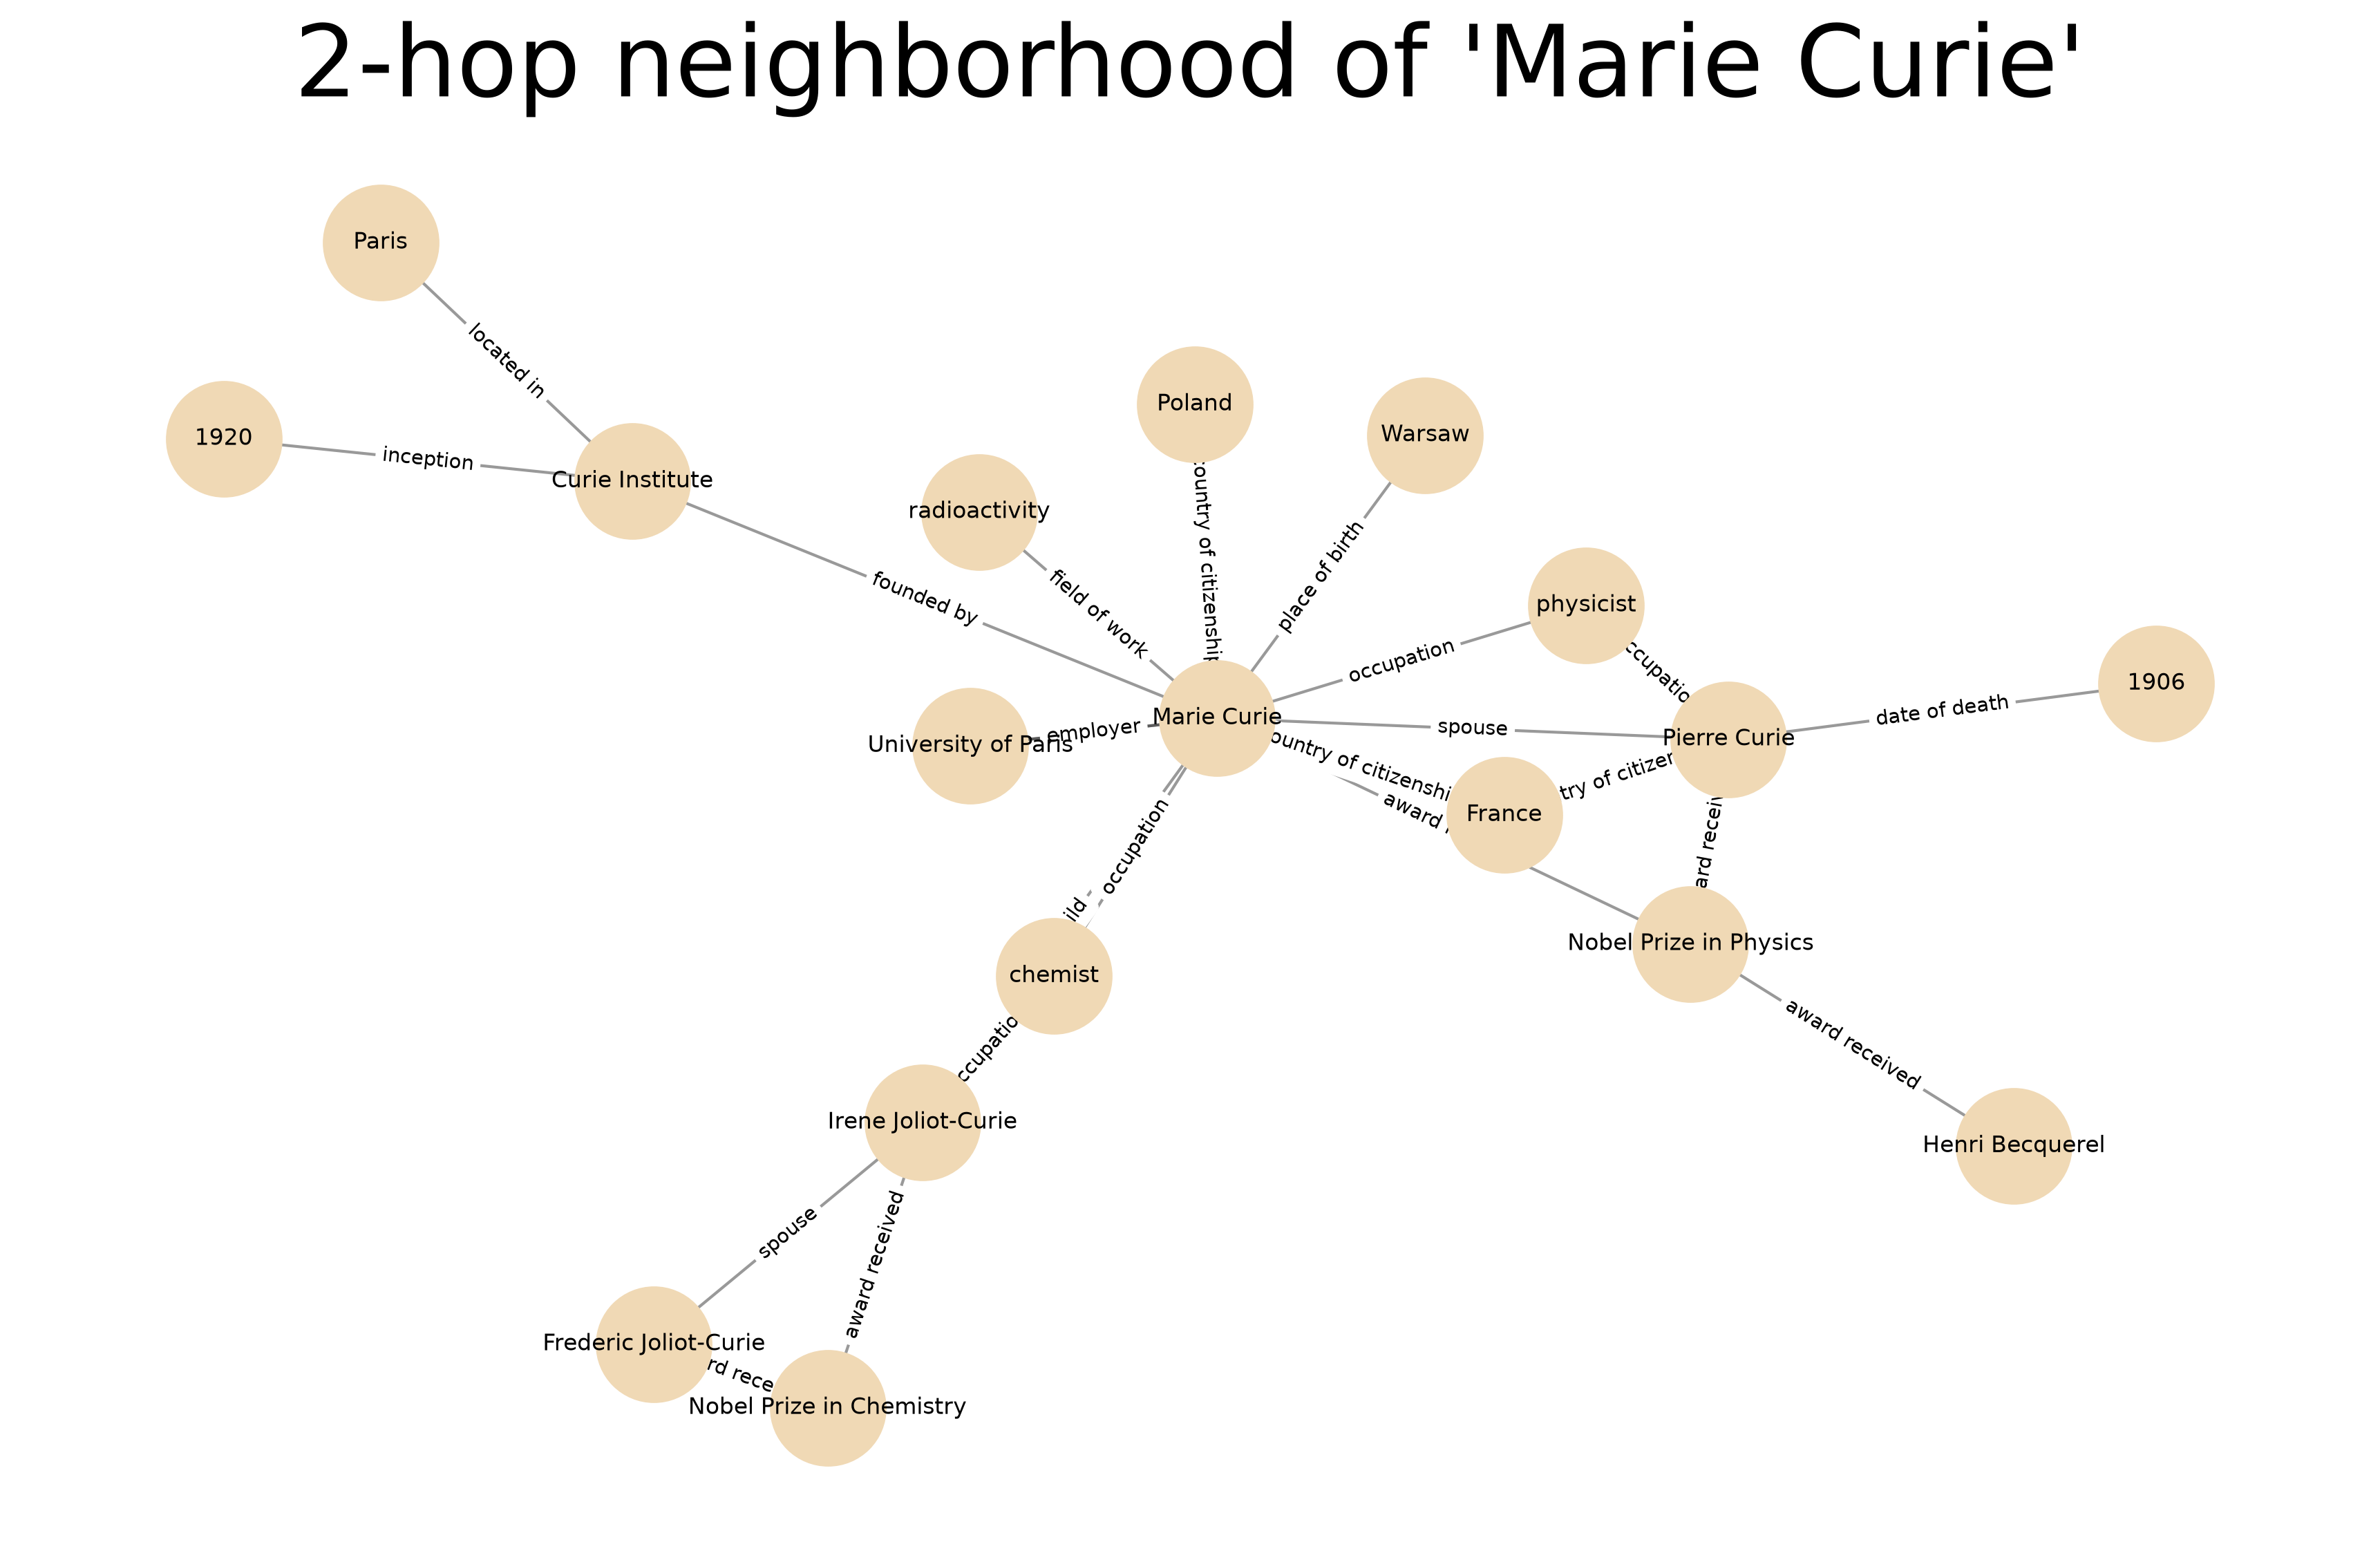

In [11]:
ego = nx.ego_graph(G.to_undirected(), hub, radius=2)
pos = nx.spring_layout(ego, seed=42)                # deterministic layout

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(ego, pos, node_color="#f0d9b5", node_size=1600)
nx.draw_networkx_labels(ego, pos, font_size=8)
nx.draw_networkx_edges(ego, pos, alpha=0.4, arrows=False)
edge_labels = {(u, v): d["relation"]
               for u, v, d in G.subgraph(ego.nodes).edges(data=True)}
nx.draw_networkx_edge_labels(ego, pos, edge_labels=edge_labels, font_size=7)
plt.title(f"2-hop neighborhood of '{hub}'")
plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# --- CHECKPOINT OUT: graph.graphml ---------------------------------------------------
# GraphML is portable XML — openable in Gephi/yEd, importable into Neo4j.
# Note: triples.jsonl remains the SOURCE OF TRUTH; Part 4 rebuilds the graph
# from triples rather than parsing GraphML, because reconstruction from triples
# is unambiguous and store-agnostic. The GraphML export is for external tools.
nx.write_graphml(G, CKPT / "graph.graphml")
print(f"[checkpoint] saved  {CKPT / 'graph.graphml'}")

# Verify the round trip works:
G_check = nx.read_graphml(CKPT / "graph.graphml")
print(f"Round-trip OK: {G_check.number_of_nodes()} nodes, "
      f"{G_check.number_of_edges()} edges")

[checkpoint] saved  checkpoints/graph.graphml
Round-trip OK: 18 nodes, 25 edges


<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>